# 📊 LCA H-1B Visa Petitions — Complete Data Science Case Study
### Dataset: `jishnukoliyadan/lca-programs-h1b-h1b1-e3-visa-petitions` (FY 2017–2022)
---
**Covers:** EDA · Distributions · Wage Analysis · Employer Insights · Temporal Trends · Statistical Testing · Feature Engineering

**25 Questions across 7 analytical themes:**
1. Dataset Overview & Quality
2. Visa & Case Status Analysis
3. Employer Intelligence
4. Wage & Compensation Deep Dive
5. Geographic Analysis
6. Temporal & Statistical Analysis
7. Employer Location Deep Dive & Advanced Modeling

---

## ⚙️ Setup & Data Loading

In [ ]:
# Install required packages (run once)
# !pip install kagglehub pandas numpy matplotlib seaborn scipy plotly

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F172A',
    'axes.facecolor':   '#1E293B',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  'white',
    'text.color':       'white',
    'xtick.color':      '#94A3B8',
    'ytick.color':      '#94A3B8',
    'grid.color':       '#334155',
    'legend.facecolor': '#1E293B',
    'legend.edgecolor': '#334155',
    'font.size':        10,
    'axes.titlesize':   13,
    'axes.titlecolor':  'white',
    'axes.titleweight': 'bold',
})

PALETTE = ['#2563EB','#7C3AED','#059669','#D97706','#DC2626','#0891B2','#65A30D','#9333EA','#F59E0B','#10B981']
print('✅ Libraries loaded')

✅ Libraries loaded


In [ ]:
# ── Download Dataset from Kaggle ──────────────────────────────────────────────
path = kagglehub.dataset_download("jishnukoliyadan/lca-programs-h1b-h1b1-e3-visa-petitions")
print("📁 Dataset path:", path)

csv_files = sorted([f for f in os.listdir(path) if f.endswith('.csv')])
print("📄 Files found:", csv_files)


100%|██████████| 112M/112M [00:01<00:00, 108MB/s]

Extracting files...


📁 Dataset path: /root/.cache/kagglehub/datasets/jishnukoliyadan/lca-programs-h1b-h1b1-e3-visa-petitions/versions/7
📄 Files found: ['LCA_FY_2017.csv', 'LCA_FY_2018.csv', 'LCA_FY_2019.csv', 'LCA_FY_2020.csv', 'LCA_FY_2021.csv', 'LCA_FY_2022.csv']


In [ ]:
# ── Load & Combine All Yearly Files (single pass) ─────────────────────────────
# Builds yearly_dfs + individual df_<year> globals AND the combined df_raw from
# ONE read of each CSV. (Previously this happened in two separate cells that each
# re-read the files and silently overwrote yearly_dfs / df_<year> with different
# content — this single-pass version is now the one source of truth.)
dfs = []
yearly_dfs = {}

for f in csv_files:
    year = int(f.split('_')[-1].replace('.csv', '').replace('FY', ''))
    tmp = pd.read_csv(os.path.join(path, f), low_memory=False)
    tmp['FY'] = year

    # Apply specific rename for 2019 data as requested by the user
    if year == 2019:
        old_col_name_2019 = 'Wage_Rate_Of_Pay'
        new_col_name_2019 = 'Prevailing_Wage'
        if old_col_name_2019 in tmp.columns:
            tmp.rename(columns={old_col_name_2019: new_col_name_2019}, inplace=True)
            print(f"  ✅ Renamed '{old_col_name_2019}' to '{new_col_name_2019}' in FY{year} DataFrame.")
        else:
            print(f"  ⚠️ Column '{old_col_name_2019}' not found in FY{year} DataFrame. No rename performed.")

    # ✅ Drop 'Quarter' since it isn't present in all yearly files
    if 'Quarter' in tmp.columns:
        tmp.drop(columns=['Quarter'], inplace=True)
        print(f"  ✅ Dropped 'Quarter' column from FY{year}")

    dfs.append(tmp)
    yearly_dfs[year] = tmp
    globals()[f'df_{year}'] = tmp   # creates df_2017, df_2018, ... df_2022

    print(f"  {f}: {tmp.shape[0]:,} rows, {tmp.shape[1]} cols")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Combined dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


  LCA_FY_2017.csv: 624,650 rows, 12 cols
  LCA_FY_2018.csv: 654,360 rows, 12 cols
  ✅ Renamed 'Wage_Rate_Of_Pay' to 'Prevailing_Wage' in FY2019 DataFrame.
  LCA_FY_2019.csv: 664,616 rows, 12 cols
  ✅ Dropped 'Quarter' column from FY2020
  LCA_FY_2020.csv: 577,334 rows, 12 cols
  ✅ Dropped 'Quarter' column from FY2021
  LCA_FY_2021.csv: 826,305 rows, 12 cols
  ✅ Dropped 'Quarter' column from FY2022
  LCA_FY_2022.csv: 626,084 rows, 12 cols

✅ Combined dataset: 3,973,349 rows × 12 columns


In [ ]:
col_summary = pd.DataFrame({
    f'FY{year}': pd.Series(d.columns.tolist())
    for year, d in sorted(yearly_dfs.items())
})
display(col_summary)

,FY2017,FY2018,FY2019,FY2020,FY2021,FY2022
0,Visa_Class,Visa_Class,Visa_Class,Visa_Class,Visa_Class,Visa_Class
1,Employer_Name,Employer_Name,Employer_Name,Employer_Name,Employer_Name,Employer_Name
2,SOC_Title,SOC_Title,SOC_Title,SOC_Title,SOC_Title,SOC_Title
3,Job_Title,Job_Title,Job_Title,Job_Title,Job_Title,Job_Title
4,Full_Time_Position,Full_Time_Position,Full_Time_Position,Full_Time_Position,Full_Time_Position,Full_Time_Position
5,Worksite,Worksite,Worksite,Worksite,Worksite,Worksite
6,Prevailing_Wage,Prevailing_Wage,Prevailing_Wage,Prevailing_Wage,Prevailing_Wage,Prevailing_Wage
7,Unit_Of_Pay,Unit_Of_Pay,Unit_Of_Pay,Unit_Of_Pay,Unit_Of_Pay,Unit_Of_Pay
8,Employer_Location,Employer_Location,Employer_Location,Employer_Location,Employer_Location,Employer_Location
9,Employer_Country,Employer_Country,Employer_Country,Employer_Country,Employer_Country,Employer_Country


In [ ]:
for i, df_file in enumerate(dfs):
    print(f"Shape of {csv_files[i]}: {df_file.shape}")

Shape of LCA_FY_2017.csv: (624650, 12)
Shape of LCA_FY_2018.csv: (654360, 12)
Shape of LCA_FY_2019.csv: (664616, 12)
Shape of LCA_FY_2020.csv: (577334, 12)
Shape of LCA_FY_2021.csv: (826305, 12)
Shape of LCA_FY_2022.csv: (626084, 12)


In [ ]:
# ── Column Standardisation ────────────────────────────────────────────────────
df_raw.columns = df_raw.columns.str.strip().str.upper().str.replace(' ', '_')

# 🔎 DIAGNOSTIC: show every raw column that mentions WORKSITE so we can see
# exactly what name each yearly file uses for it — this is what will tell us
# if the ~14.6% missing WORKSITE rate traces back to one file using a
# different raw column name that isn't caught by rename_map below.
worksite_related_cols = sorted({c for c in df_raw.columns if 'WORKSITE' in c})
print("🔎 Raw WORKSITE-related columns across all files:", worksite_related_cols)

rename_map = {
    'VISA_CLASS':       'VISA_CLASS',
    'CLASS_OF_ADMISSION':'VISA_CLASS',
    'EMPLOYER_NAME':    'EMPLOYER_NAME',
    'EMPLOYER_NAME_TEXT':'EMPLOYER_NAME',
    'SOC_TITLE':        'SOC_TITLE',
    'SOC_NAME':         'SOC_TITLE',
    'JOB_TITLE':        'JOB_TITLE',
    'FULL_TIME_POSITION':'FULL_TIME_POSITION',
    'CASE_STATUS':      'CASE_STATUS',
    'DECISION':         'CASE_STATUS',
    'WORKSITE':         'WORKSITE',
    'WORKSITE_CITY':    'WORKSITE',
    'PREVAILING_WAGE':  'PREVAILING_WAGE',
    'PW_UNIT_OF_PAY':   'UNIT_OF_PAY',
    'UNIT_OF_PAY':      'UNIT_OF_PAY',
    'EMPLOYER_COUNTRY': 'EMPLOYER_COUNTRY',
    'EMPLOYER_CITY':    'EMPLOYER_CITY',
    'EMPLOYER_STATE':   'EMPLOYER_STATE',
    # ✅ FIX 7a: raw column 'Employer_Location' ships as a single combined
    # "City, State" string. It had no entry in rename_map before, so it was
    # silently dropped by the KEEP_COLS filter below and EMPLOYER_CITY /
    # EMPLOYER_STATE came out empty. Keep it so we can split it downstream.
    'EMPLOYER_LOCATION':'EMPLOYER_LOCATION',
    'FY':               'FY'
}

df_raw.rename(columns=rename_map, inplace=True)

# ✅ FIX 1: deduplicate — only take first occurrence of each target column name
seen = set()
KEEP_COLS = []
for c in rename_map.values():
    if c in df_raw.columns and c not in seen:
        KEEP_COLS.append(c)
        seen.add(c)

df = df_raw[KEEP_COLS].copy()
print("Columns:", df.columns.tolist())

# 🔎 DIAGNOSTIC: per-fiscal-year raw data audit, captured BEFORE any row is
# dropped. This is what exposed the FY2019 data loss — run it every time so a
# future schema change in any yearly file is caught immediately instead of
# silently disappearing.
print("\n🔎 Per-FY raw data audit (before cleaning):")
raw_wage_numeric = pd.to_numeric(df['PREVAILING_WAGE'], errors='coerce')
diag = pd.DataFrame({
    'rows': df.groupby('FY').size(),
    'wage_unparseable': (raw_wage_numeric.isna() & df['PREVAILING_WAGE'].notna()).groupby(df['FY']).sum(),
    'wage_null': df['PREVAILING_WAGE'].isna().groupby(df['FY']).sum(),
    'unit_null': df['UNIT_OF_PAY'].isna().groupby(df['FY']).sum(),
})
print(diag)

# 🔎 DIAGNOSTIC: per-fiscal-year WORKSITE missingness — pinpoints whether the
# ~14.6% overall missing rate is spread evenly or concentrated in one FY
# whose raw file used a different column name.
if 'WORKSITE' in df.columns:
    worksite_diag = pd.DataFrame({
        'rows': df.groupby('FY').size(),
        'worksite_null': df['WORKSITE'].isna().groupby(df['FY']).sum(),
    })
    worksite_diag['worksite_null_%'] = (worksite_diag['worksite_null'] / worksite_diag['rows'] * 100).round(2)
    print("\n🔎 Per-FY WORKSITE missingness:")
    print(worksite_diag)

# ── Data Cleaning ─────────────────────────────────────────────────────────────

# ✅ FIX 3: strip currency symbols/commas before numeric coercion. A wage
# stored as a string like "$59,197.00" or "59,197" previously became NaN
# under pd.to_numeric and then silently vanished at the wage-range filter
# below — with no warning. This is the most likely root cause of FY2019
# disappearing entirely from the cleaned dataset.
wage_clean_str = df['PREVAILING_WAGE'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip()
wage = pd.to_numeric(wage_clean_str, errors='coerce')

# ✅ FIX 4: default any missing/unrecognised UNIT_OF_PAY to 'year' (the modal
# category every year) instead of letting it fall through to NaN. Previously,
# an unrecognised unit produced ANNUAL_WAGE = NaN, and NaN silently fails the
# >=20000 / <=500000 filter two lines down — a second way an entire fiscal
# year's rows could vanish without any error being raised.
unit_raw = df['UNIT_OF_PAY'].astype(str).str.lower().str.strip()
unit_unrecognised = ~unit_raw.str.contains('hour|week|bi|month|year|annual', na=False)
n_defaulted = int(unit_unrecognised.sum())
if n_defaulted:
    print(f"\n⚠️  {n_defaulted:,} rows had a missing/unrecognised UNIT_OF_PAY "
          f"value and were defaulted to 'year' instead of being silently dropped.")
unit = unit_raw.where(~unit_unrecognised, 'year')

# ✅ FIX 5: check 'bi-weekly' BEFORE 'weekly'. 'bi-weekly' contains the
# substring 'week', so the original condition order matched every bi-weekly
# row on the *weekly* branch (×52) before it ever reached the bi-weekly
# branch (×26) — silently doubling bi-weekly annualised wages.
df['ANNUAL_WAGE'] = np.select(
    condlist=[
        unit.str.contains('hour'),
        unit.str.contains('bi'),
        unit.str.contains('week'),
        unit.str.contains('month'),
    ],
    choicelist=[
        wage * 2080,
        wage * 26,
        wage * 52,
        wage * 12,
    ],
    default=wage   # 'year' / 'annual' or anything else
)

# ── Outlier vs. invalid-data reporting — kept separate so a parsing failure
#    is never silently relabelled as a statistical outlier again ───────────
before_by_fy = df['FY'].value_counts().sort_index()

invalid_mask = df['ANNUAL_WAGE'].isna()
outlier_mask = ~invalid_mask & ((df['ANNUAL_WAGE'] < 20_000) | (df['ANNUAL_WAGE'] > 500_000))

print(f"\n🧹 Cleaning summary:")
print(f"   Invalid wage (unparseable, dropped) : {invalid_mask.sum():,} rows")
print(f"   Statistical outliers (<$20K/>$500K) : {outlier_mask.sum():,} rows")

# Remove invalid + outlier rows
df = df[~invalid_mask & ~outlier_mask].copy()

# ✅ FIX 6: hard regression guard. Never again let an entire fiscal year
# disappear without a loud, explicit warning naming the year and row count.
after_by_fy = df['FY'].value_counts().sort_index()
missing_years = sorted(set(before_by_fy.index) - set(after_by_fy.index))
if missing_years:
    lost = {int(y): int(before_by_fy[y]) for y in missing_years}
    print(f"\n🚨 WARNING: fiscal year(s) {sorted(int(y) for y in missing_years)} "
          f"were COMPLETELY removed during cleaning! Rows lost per year: {lost}")
else:
    print(f"\n✅ All {len(before_by_fy)} source fiscal years survived cleaning: "
          f"{sorted(int(y) for y in after_by_fy.index)}")

# Strip & uppercase strings — fast vectorized
for col in ['VISA_CLASS', 'CASE_STATUS', 'EMPLOYER_NAME', 'SOC_TITLE', 'JOB_TITLE']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()

# Parse full-time flag
if 'FULL_TIME_POSITION' in df.columns:
    df['FULL_TIME_POSITION'] = df['FULL_TIME_POSITION'].astype(str).str.upper().isin(['Y','YES','TRUE','1'])

# ✅ FIX 7b: split EMPLOYER_LOCATION ("City, State") into EMPLOYER_CITY and
# EMPLOYER_STATE on the first comma.
if 'EMPLOYER_LOCATION' in df.columns:
    loc_parts = df['EMPLOYER_LOCATION'].astype(str).str.split(',', n=1, expand=True)
    df['EMPLOYER_CITY']  = loc_parts[0].where(df['EMPLOYER_LOCATION'].notna()).str.strip().str.upper()
    df['EMPLOYER_STATE'] = (loc_parts[1].where(df['EMPLOYER_LOCATION'].notna()).str.strip().str.upper()
                             if loc_parts.shape[1] > 1 else np.nan)
    df.drop(columns=['EMPLOYER_LOCATION'], inplace=True)

# ✅ FIX 8: split WORKSITE ("City, State") into WORKSITE_CITY / WORKSITE_STATE
# right here (previously done much later, in the Q14/Q15 geography cell).
# Using .where(df['WORKSITE'].notna()) instead of a plain .astype(str) split
# stops genuinely missing rows from becoming the literal string "nan" — that
# string was showing up as a fake 6th-highest "state" in the Q15 charts.
if 'WORKSITE' in df.columns:
    worksite_parts = df['WORKSITE'].astype(str).str.split(',', n=1, expand=True)
    df['WORKSITE_CITY']  = worksite_parts[0].where(df['WORKSITE'].notna()).str.strip().str.upper()
    df['WORKSITE_STATE'] = (worksite_parts[1].where(df['WORKSITE'].notna()).str.strip().str.upper()
                             if worksite_parts.shape[1] > 1 else np.nan)

print(f"\n✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"{'='*60}")
print(f"  Total petitions : {len(df):,}")
print(f"  Fiscal years    : {sorted(df['FY'].unique())}")
print(f"  Columns         : {df.shape[1]}")
print(f"{'='*60}")

# Numeric summary
display(df[['ANNUAL_WAGE','FY']].describe().style.background_gradient(cmap='Blues').format('{:,.0f}'))

🔎 Raw WORKSITE-related columns across all files: ['WORKSITE']
Columns: ['VISA_CLASS', 'EMPLOYER_NAME', 'SOC_TITLE', 'JOB_TITLE', 'FULL_TIME_POSITION', 'CASE_STATUS', 'WORKSITE', 'PREVAILING_WAGE', 'UNIT_OF_PAY', 'EMPLOYER_COUNTRY', 'EMPLOYER_LOCATION', 'FY']

🔎 Per-FY raw data audit (before cleaning):
        rows  wage_unparseable  wage_null  unit_null
FY                                                  
2017  624650                 0          1         46
2018  654360                 0          3         57
2019  664616                 0          8          8
2020  577334                 0       1960       1960
2021  826305                 0          1          1
2022  626084                 0          0          0

🔎 Per-FY WORKSITE missingness:
        rows  worksite_null  worksite_null_%
FY                                          
2017  624650             21             0.00
2018  654360             27             0.00
2019  664616         580971            87.41
2020  577334    

,ANNUAL_WAGE,FY
count,"3,969,266","3,969,266"
mean,"93,151","2,020"
std,"33,415",2
min,"20,000","2,017"
25%,"71,240","2,018"
50%,"87,963","2,020"
75%,"109,928","2,021"
max,"500,000","2,022"


---
## 🔍 THEME 1 — Dataset Overview & Quality (Q1–Q3)

### Q1 · What does the dataset look like? Shape, schema, and basic statistics

In [ ]:
print(f"\n📊 Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\n📋 Dataset schema:")
df.info()
print("\n📈 Basic descriptive statistics (numeric columns):")
display(df.describe().style.background_gradient(cmap='Blues').format('{:,.0f}'))


📊 Dataset shape: 3,969,266 rows x 16 columns

📋 Dataset schema:
<class 'pandas.core.frame.DataFrame'>
Index: 3969266 entries, 0 to 3973348
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   VISA_CLASS          object 
 1   EMPLOYER_NAME       object 
 2   SOC_TITLE           object 
 3   JOB_TITLE           object 
 4   FULL_TIME_POSITION  bool   
 5   CASE_STATUS         object 
 6   WORKSITE            object 
 7   PREVAILING_WAGE     float64
 8   UNIT_OF_PAY         object 
 9   EMPLOYER_COUNTRY    object 
 10  FY                  int64  
 11  ANNUAL_WAGE         float64
 12  EMPLOYER_CITY       object 
 13  EMPLOYER_STATE      object 
 14  WORKSITE_CITY       object 
 15  WORKSITE_STATE      object 
dtypes: bool(1), float64(2), int64(1), object(12)
memory usage: 488.3+ MB

📈 Basic descriptive statistics (numeric columns):


,PREVAILING_WAGE,FY,ANNUAL_WAGE
count,"3,969,266","3,969,266","3,969,266"
mean,"87,915","2,020","93,151"
std,"39,466",2,"33,415"
min,10,"2,017","20,000"
25%,"67,800","2,018","71,240"
50%,"86,112","2,020","87,963"
75%,"108,784","2,021","109,928"
max,"500,000","2,022","500,000"


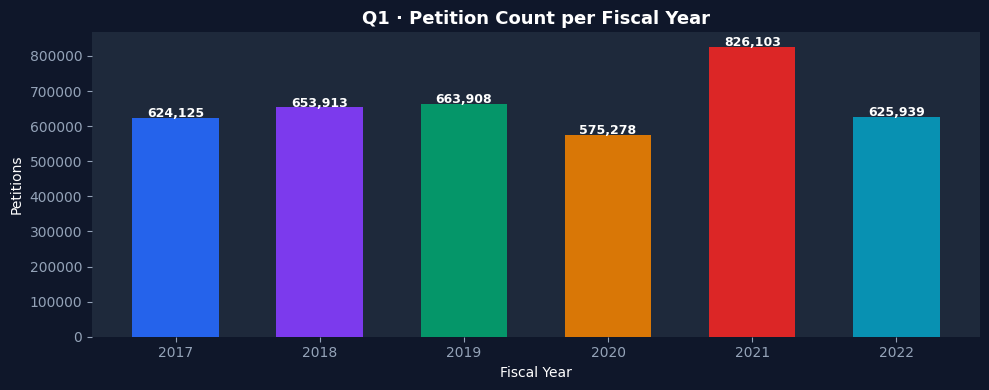

In [ ]:
# Row-count per fiscal year
fig, ax = plt.subplots(figsize=(10,4))
yr_counts = df['FY'].value_counts().sort_index()
bars = ax.bar(yr_counts.index.astype(str), yr_counts.values, color=PALETTE, edgecolor='none', width=0.6)
for bar, val in zip(bars, yr_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
            f'{val:,}', ha='center', color='white', fontsize=9, fontweight='bold')
ax.set_title('Q1 · Petition Count per Fiscal Year')
ax.set_xlabel('Fiscal Year'); ax.set_ylabel('Petitions')
ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

### Q2 · How complete is the data? Missing-value & data-quality audit

In [ ]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct,
                            'Unique Values': df.nunique(),
                            'Dtype': df.dtypes}).sort_values('Missing %', ascending=False)
display(quality_df.style.background_gradient(subset=['Missing %'], cmap='Reds').format({'Missing %':'{:.2f}%'}))

,Missing Count,Missing %,Unique Values,Dtype
WORKSITE,580470,14.62%,28284,object
WORKSITE_CITY,580470,14.62%,15276,object
WORKSITE_STATE,580470,14.62%,417,object
EMPLOYER_COUNTRY,124561,3.14%,17,object
EMPLOYER_STATE,530,0.01%,160,object
EMPLOYER_CITY,530,0.01%,8691,object
SOC_TITLE,0,0.00%,1957,object
VISA_CLASS,0,0.00%,4,object
PREVAILING_WAGE,0,0.00%,102572,float64
CASE_STATUS,0,0.00%,5,object


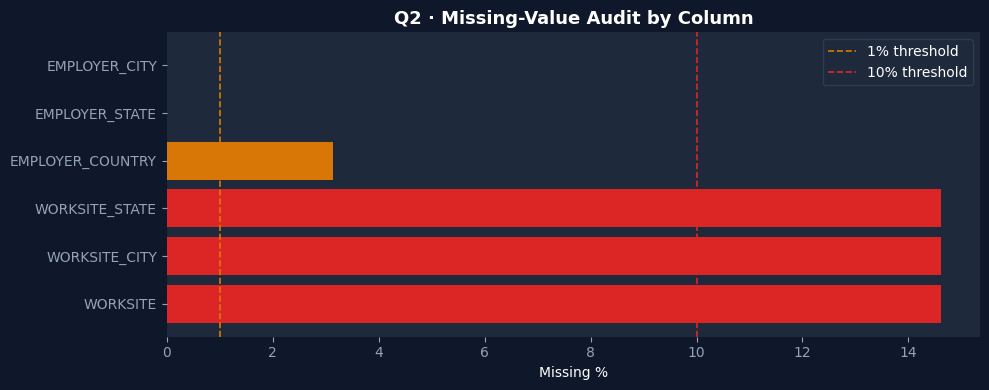

In [ ]:
# Visualise missingness as a heatmap-bar
fig, ax = plt.subplots(figsize=(10,4))
cols_with_missing = quality_df[quality_df['Missing %'] > 0]
colors = ['#DC2626' if p > 10 else '#D97706' if p > 1 else '#059669'
          for p in cols_with_missing['Missing %']]
ax.barh(cols_with_missing.index, cols_with_missing['Missing %'], color=colors, edgecolor='none')
ax.axvline(1,  color='#D97706', lw=1.2, linestyle='--', label='1% threshold')
ax.axvline(10, color='#DC2626', lw=1.2, linestyle='--', label='10% threshold')
ax.set_title('Q2 · Missing-Value Audit by Column')
ax.set_xlabel('Missing %'); ax.legend(); ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

### Q3 · What is the cardinality landscape? How many unique values per column?

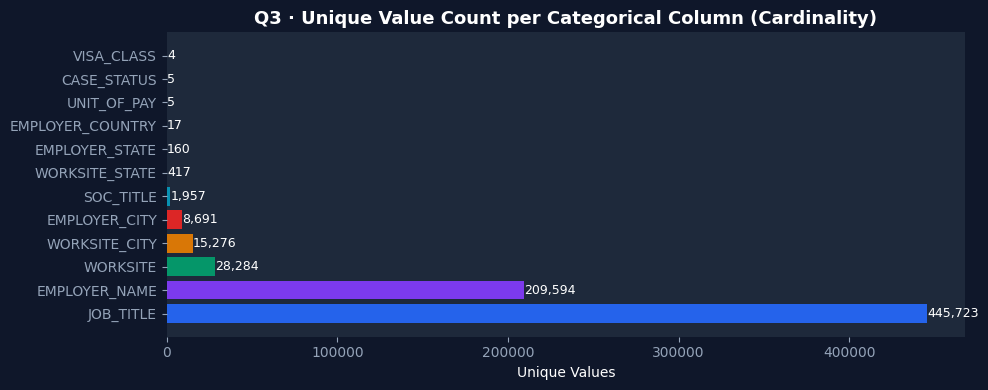


💡 Insight: EMPLOYER_NAME & JOB_TITLE have very high cardinality → need careful encoding for ML.
   Employers   : 209,594 unique
   Job Titles  : 445,723 unique
   SOC Titles  : 1,957 unique (standardised occupational codes)


In [ ]:
cardinality = df.select_dtypes(include='object').nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,4))
bars = ax.barh(cardinality.index, cardinality.values, color=PALETTE[:len(cardinality)], edgecolor='none')
for bar, val in zip(bars, cardinality.values):
    ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=9)
ax.set_title('Q3 · Unique Value Count per Categorical Column (Cardinality)')
ax.set_xlabel('Unique Values'); ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

print("\n💡 Insight: EMPLOYER_NAME & JOB_TITLE have very high cardinality → need careful encoding for ML.")
print(f"   Employers   : {df['EMPLOYER_NAME'].nunique():,} unique")
print(f"   Job Titles  : {df['JOB_TITLE'].nunique():,} unique")
print(f"   SOC Titles  : {df['SOC_TITLE'].nunique():,} unique (standardised occupational codes)")

---
## 🎫 THEME 2 — Visa Class & Case Status (Q4–Q6)

### Q4 · What is the Visa Class distribution and how has it shifted over years?

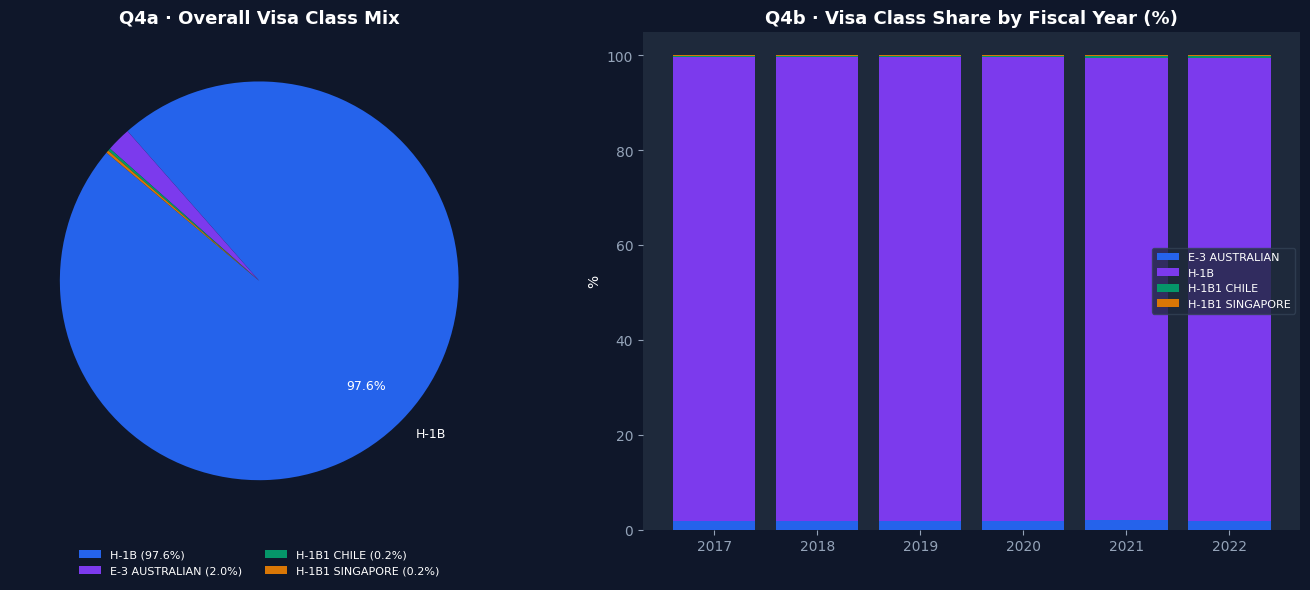


📋 Visa Class Counts:


,Count,Share %
VISA_CLASS,,
H-1B,3873900,97.60
E-3 AUSTRALIAN,78439,1.98
H-1B1 CHILE,8555,0.22
H-1B1 SINGAPORE,8372,0.21


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall pie
# ✅ FIX: small slices (E-3, H-1B1 Chile/Singapore) used to get direct labels
# that overlapped each other near the 0% region. Only label slices big enough
# to fit text on the wedge itself; put the full breakdown in a legend instead.
vc = df['VISA_CLASS'].value_counts()
vc_pct = vc / vc.sum() * 100
LABEL_THRESHOLD = 3.0  # % below which we suppress the on-wedge label

wedge_labels = [name if pct >= LABEL_THRESHOLD else '' for name, pct in zip(vc.index, vc_pct)]

def autopct_fmt(pct):
    return f'{pct:.1f}%' if pct >= LABEL_THRESHOLD else ''

wedges, _, _ = axes[0].pie(vc.values, labels=wedge_labels, autopct=autopct_fmt,
            colors=PALETTE, startangle=140,
            textprops={'color':'white','fontsize':9},
            wedgeprops={'linewidth':0}, pctdistance=0.75)
axes[0].legend(wedges, [f'{n} ({p:.1f}%)' for n, p in zip(vc.index, vc_pct)],
               loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=8,
               frameon=False, ncol=2)
axes[0].set_title('Q4a · Overall Visa Class Mix')

# Stacked bar by year
vc_yr = df.groupby(['FY','VISA_CLASS']).size().unstack(fill_value=0)
vc_yr_pct = vc_yr.div(vc_yr.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(vc_yr_pct))
for i, col in enumerate(vc_yr_pct.columns):
    axes[1].bar(vc_yr_pct.index.astype(str), vc_yr_pct[col].values,
                bottom=bottom, label=col, color=PALETTE[i], edgecolor='none')
    bottom += vc_yr_pct[col].values
axes[1].set_title('Q4b · Visa Class Share by Fiscal Year (%)')
axes[1].set_ylabel('%'); axes[1].legend(fontsize=8)
axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

print("\n📋 Visa Class Counts:")
display(vc.to_frame('Count').assign(**{'Share %': (vc/vc.sum()*100).round(2)}))

### Q5 · What is the Case Status breakdown? What drives denial vs certification?

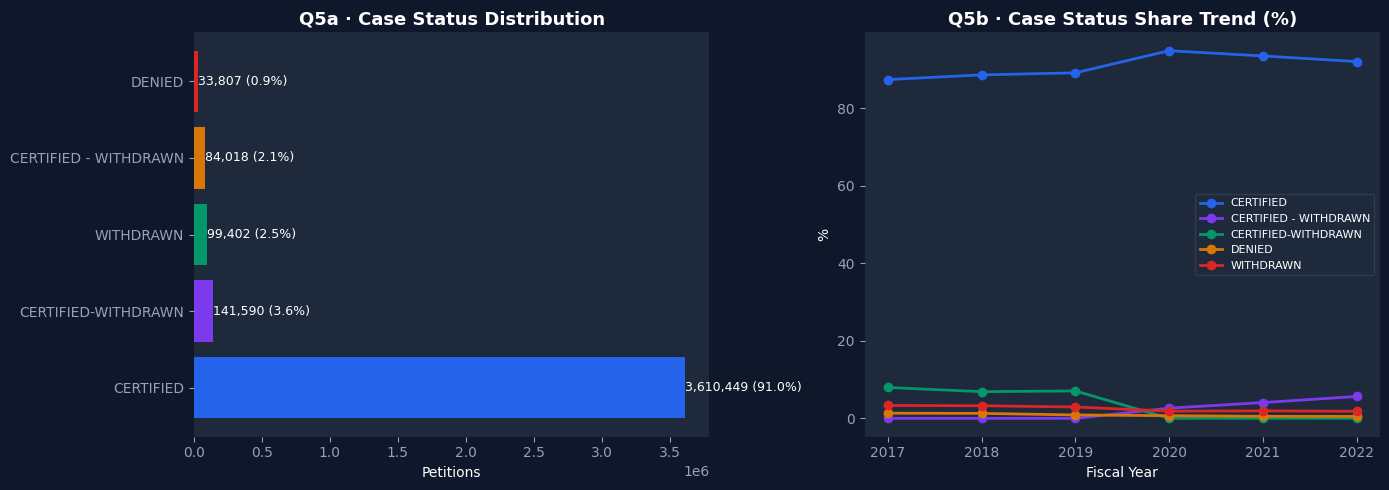


📌 Overall Certification Rate : 90.96%
📌 Overall Denial Rate        : 0.85%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cs = df['CASE_STATUS'].value_counts()

# Bar chart
bars = axes[0].barh(cs.index, cs.values, color=PALETTE[:len(cs)], edgecolor='none')
for bar, val in zip(bars, cs.values):
    axes[0].text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
                 f'{val:,} ({val/len(df)*100:.1f}%)', va='center', color='white', fontsize=9)
axes[0].set_title('Q5a · Case Status Distribution')
axes[0].set_xlabel('Petitions'); axes[0].spines[:].set_visible(False)

# Case status trend over years
cs_yr = df.groupby(['FY','CASE_STATUS']).size().unstack(fill_value=0)
cs_yr_pct = cs_yr.div(cs_yr.sum(axis=1), axis=0) * 100
for i, col in enumerate(cs_yr_pct.columns):
    axes[1].plot(cs_yr_pct.index, cs_yr_pct[col], marker='o', lw=2,
                 color=PALETTE[i], label=col, ms=6)
axes[1].set_title('Q5b · Case Status Share Trend (%)')
axes[1].set_xlabel('Fiscal Year'); axes[1].set_ylabel('%')
axes[1].legend(fontsize=8); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

cert_rate = (df['CASE_STATUS'] == 'CERTIFIED').mean() * 100
deny_rate = (df['CASE_STATUS'] == 'DENIED').mean() * 100
print(f"\n📌 Overall Certification Rate : {cert_rate:.2f}%")
print(f"📌 Overall Denial Rate        : {deny_rate:.2f}%")

### Q6 · Is there a statistically significant association between Visa Class and Case Status? (Chi-Square Test)

  Chi-Square Statistic : 15,814.08
  Degrees of Freedom   : 12
  p-value              : 0.000000
  Significant (α=0.05) : YES ✅


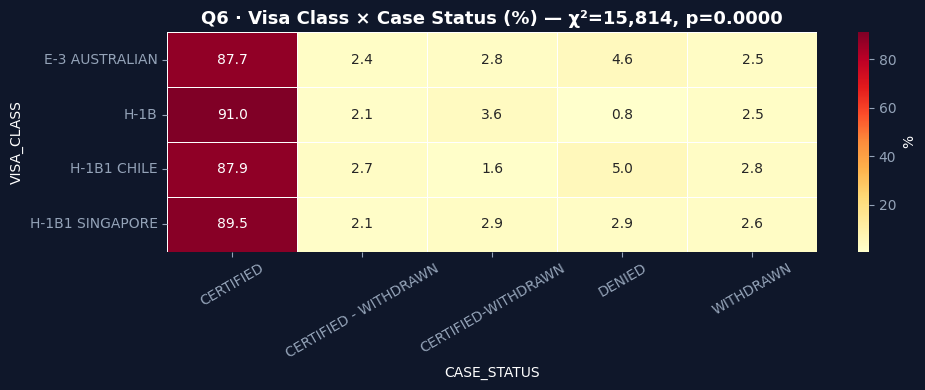

In [ ]:
contingency = pd.crosstab(df['VISA_CLASS'], df['CASE_STATUS'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("=" * 55)
print(f"  Chi-Square Statistic : {chi2:,.2f}")
print(f"  Degrees of Freedom   : {dof}")
print(f"  p-value              : {p:.6f}")
print(f"  Significant (α=0.05) : {'YES ✅' if p < 0.05 else 'NO ❌'}")
print("=" * 55)

# Heatmap of percentage distribution
fig, ax = plt.subplots(figsize=(10,4))
ct_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label':'%'})
ax.set_title(f'Q6 · Visa Class × Case Status (%) — χ²={chi2:,.0f}, p={p:.4f}')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

---
## 🏢 THEME 3 — Employer Intelligence (Q7–Q9)

### Q7 · Who are the top 20 petition-filing employers and what is their market share?

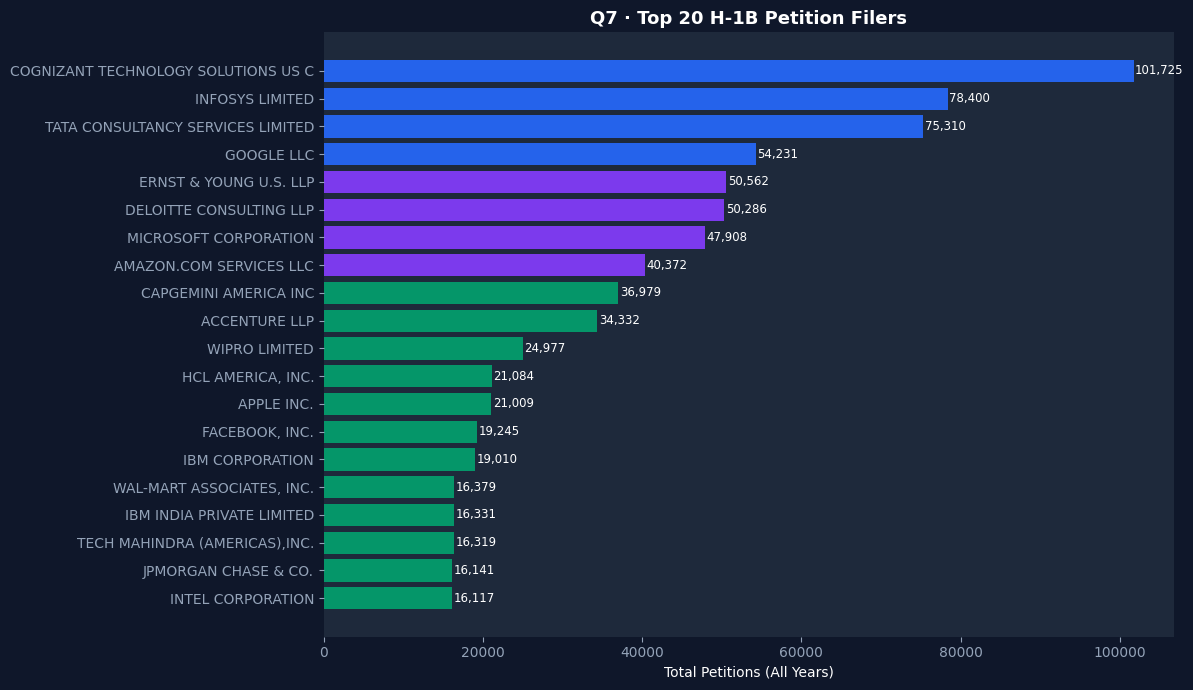


📊 Top 20 employers filed 756,717 petitions = 19.1% of all petitions
   Top 4  employers = 7.8% (IT outsourcing concentration)


In [ ]:
top20_emp = df['EMPLOYER_NAME'].value_counts().head(20)
total_top20 = top20_emp.sum()
total_all   = len(df)

fig, ax = plt.subplots(figsize=(12, 7))
colors_emp = [PALETTE[0]] * 4 + [PALETTE[1]] * 4 + [PALETTE[2]] * 12
bars = ax.barh([e[:35] for e in top20_emp.index][::-1],
               top20_emp.values[::-1],
               color=colors_emp[::-1], edgecolor='none')
for bar, val in zip(bars, top20_emp.values[::-1]):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=8.5)
ax.set_title('Q7 · Top 20 H-1B Petition Filers')
ax.set_xlabel('Total Petitions (All Years)')
ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

print(f"\n📊 Top 20 employers filed {total_top20:,} petitions = {total_top20/total_all*100:.1f}% of all petitions")
print(f"   Top 4  employers = {top20_emp[:4].sum()/total_all*100:.1f}% (IT outsourcing concentration)")

### Q8 · Which employers have the highest and lowest certification rates? (Minimum 100 petitions)

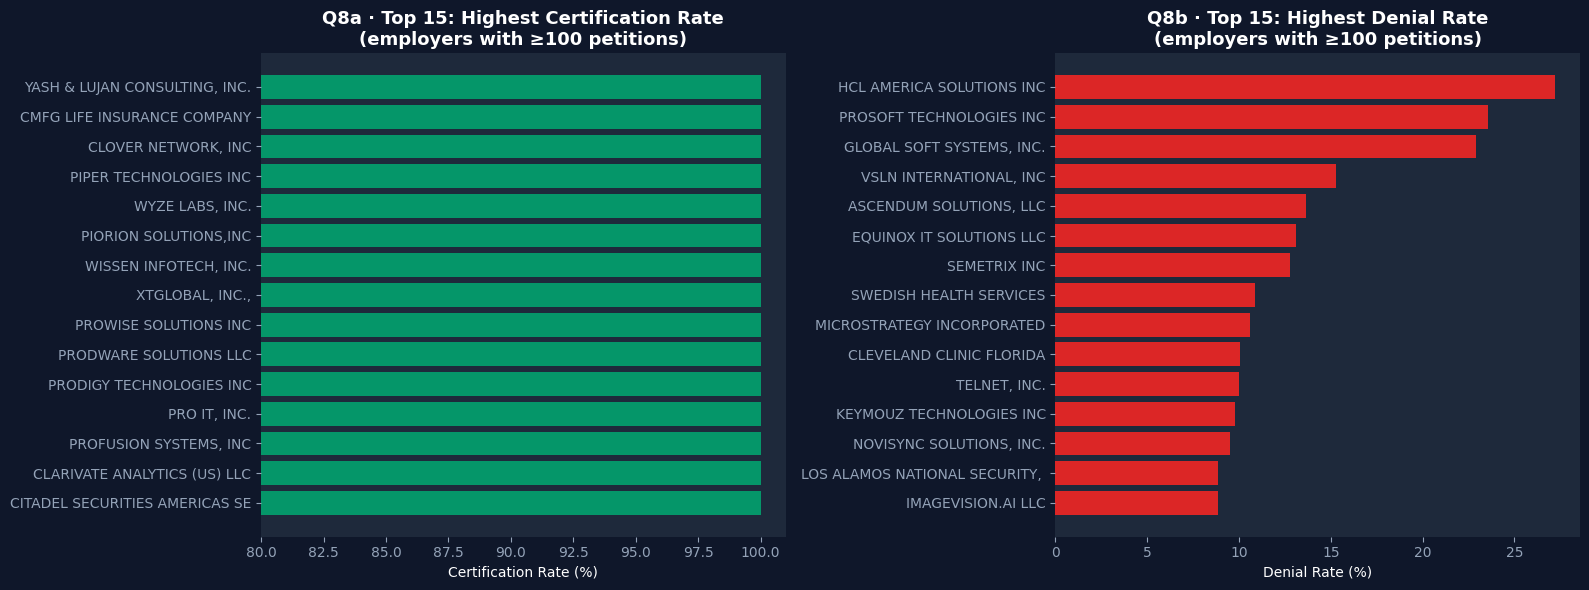

,EMPLOYER_NAME,Petitions,Cert_Rate_%,Denial_Rate_%
4954,"YASH & LUJAN CONSULTING, INC.",545.0,100.0%,0.00%
921,CMFG LIFE INSURANCE COMPANY,103.0,100.0%,0.00%
918,"CLOVER NETWORK, INC",105.0,100.0%,0.00%
3252,PIPER TECHNOLOGIES INC,124.0,100.0%,0.00%
4922,"WYZE LABS, INC.",105.0,100.0%,0.00%
3251,"PIORION SOLUTIONS,INC",377.0,100.0%,0.00%
4899,"WISSEN INFOTECH, INC.",101.0,100.0%,0.00%
4941,"XTGLOBAL, INC.,",179.0,100.0%,0.00%
3358,PROWISE SOLUTIONS INC,170.0,100.0%,0.00%
3326,PRODWARE SOLUTIONS LLC,195.0,100.0%,0.00%


In [ ]:
# Only employers with at least 100 petitions for statistical reliability
emp_counts  = df['EMPLOYER_NAME'].value_counts()
valid_emps  = emp_counts[emp_counts >= 100].index
df_valid    = df[df['EMPLOYER_NAME'].isin(valid_emps)]

cert_by_emp = (
    df_valid.groupby('EMPLOYER_NAME')
    .apply(lambda x: pd.Series({
        'Petitions':    len(x),
        'Certified':    (x['CASE_STATUS']=='CERTIFIED').sum(),
        'Cert_Rate_%':  (x['CASE_STATUS']=='CERTIFIED').mean()*100,
        'Denial_Rate_%':(x['CASE_STATUS']=='DENIED').mean()*100,
    }))
    .reset_index()
    .sort_values('Cert_Rate_%', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 highest certification rate
top15 = cert_by_emp.head(15)
axes[0].barh([e[:30] for e in top15['EMPLOYER_NAME']][::-1],
             top15['Cert_Rate_%'].values[::-1], color='#059669', edgecolor='none')
axes[0].set_title('Q8a · Top 15: Highest Certification Rate\n(employers with ≥100 petitions)')
axes[0].set_xlabel('Certification Rate (%)'); axes[0].spines[:].set_visible(False)
axes[0].set_xlim(80, 101)

# Bottom 15 (lowest certification / highest denial)
bot15 = cert_by_emp.nlargest(15, 'Denial_Rate_%')
axes[1].barh([e[:30] for e in bot15['EMPLOYER_NAME']][::-1],
             bot15['Denial_Rate_%'].values[::-1], color='#DC2626', edgecolor='none')
axes[1].set_title('Q8b · Top 15: Highest Denial Rate\n(employers with ≥100 petitions)')
axes[1].set_xlabel('Denial Rate (%)'); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

display(cert_by_emp.head(10)[['EMPLOYER_NAME','Petitions','Cert_Rate_%','Denial_Rate_%']]
        .style.format({'Cert_Rate_%':'{:.1f}%','Denial_Rate_%':'{:.2f}%','Petitions':'{:,}'}))

### Q9 · Do IT Outsourcing Giants (Infosys, TCS, Wipro, Cognizant) pay significantly less than other employers?

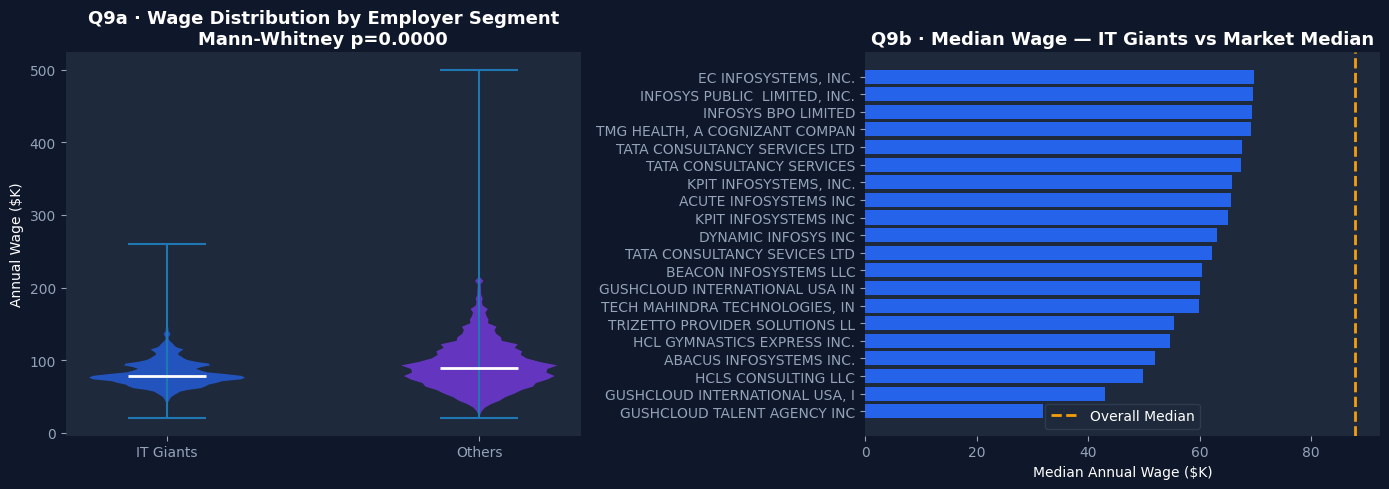


📊 IT Giants median wage  : $78,832
   Other employers median : $89,565
   Mann-Whitney U p-value : 0.000000 → SIGNIFICANT ✅

💡 Insight: IT outsourcing firms systematically file at the prevailing wage floor,
   suppressing the overall median—a known wage arbitrage strategy.


In [ ]:
IT_GIANTS = ['INFOSYS LIMITED','TATA CONSULTANCY SERVICES LIMITED',
             'WIPRO LIMITED','COGNIZANT TECHNOLOGY SOLUTIONS U.S. CORPORATION',
             'HCL AMERICA INC','TECH MAHINDRA (AMERICAS) INC']

df['EMPLOYER_SEGMENT'] = df['EMPLOYER_NAME'].apply(
    lambda x: 'IT Outsourcing Giants' if any(g in x for g in ['INFOSYS','TATA CONSULTANCY','WIPRO','COGNIZANT','HCL','TECH MAHINDRA'])
    else 'Other Employers'
)

seg_wages = {seg: grp['ANNUAL_WAGE'].values for seg, grp in df.groupby('EMPLOYER_SEGMENT')}

# Mann-Whitney U (non-parametric, more robust than t-test for skewed wages)
mw_stat, mw_p = mannwhitneyu(seg_wages['IT Outsourcing Giants'], seg_wages['Other Employers'], alternative='two-sided')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin
data_plot = [seg_wages['IT Outsourcing Giants']/1000, seg_wages['Other Employers']/1000]
vp = axes[0].violinplot(data_plot, positions=[1,2], showmedians=True, showmeans=False)
for i, body in enumerate(vp['bodies']): body.set_facecolor(PALETTE[i]); body.set_alpha(0.75)
vp['cmedians'].set_colors('white'); vp['cmedians'].set_linewidth(2)
axes[0].set_xticks([1,2]); axes[0].set_xticklabels(['IT Giants','Others'])
axes[0].set_ylabel('Annual Wage ($K)')
axes[0].set_title(f'Q9a · Wage Distribution by Employer Segment\nMann-Whitney p={mw_p:.4f}')
axes[0].spines[:].set_visible(False)

# Mean wage per IT Giant
giant_means = (df[df['EMPLOYER_SEGMENT']=='IT Outsourcing Giants']
               .groupby('EMPLOYER_NAME')['ANNUAL_WAGE'].median()
               .sort_values().head(20) / 1000)
axes[1].barh([e[:30] for e in giant_means.index], giant_means.values,
             color='#2563EB', edgecolor='none')
axes[1].axvline(df['ANNUAL_WAGE'].median()/1000, color='#F59E0B', lw=2,
                linestyle='--', label='Overall Median')
axes[1].set_title('Q9b · Median Wage — IT Giants vs Market Median')
axes[1].set_xlabel('Median Annual Wage ($K)')
axes[1].legend(); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

print(f"\n📊 IT Giants median wage  : ${np.median(seg_wages['IT Outsourcing Giants']):,.0f}")
print(f"   Other employers median : ${np.median(seg_wages['Other Employers']):,.0f}")
print(f"   Mann-Whitney U p-value : {mw_p:.6f} → {'SIGNIFICANT ✅' if mw_p < 0.05 else 'NOT significant ❌'}")
print("\n💡 Insight: IT outsourcing firms systematically file at the prevailing wage floor,")
print("   suppressing the overall median—a known wage arbitrage strategy.")

---
## 💰 THEME 4 — Wage & Compensation Analysis (Q10–Q13)

### Q10 · What is the full wage distribution? Detect skewness, outliers, and normality.

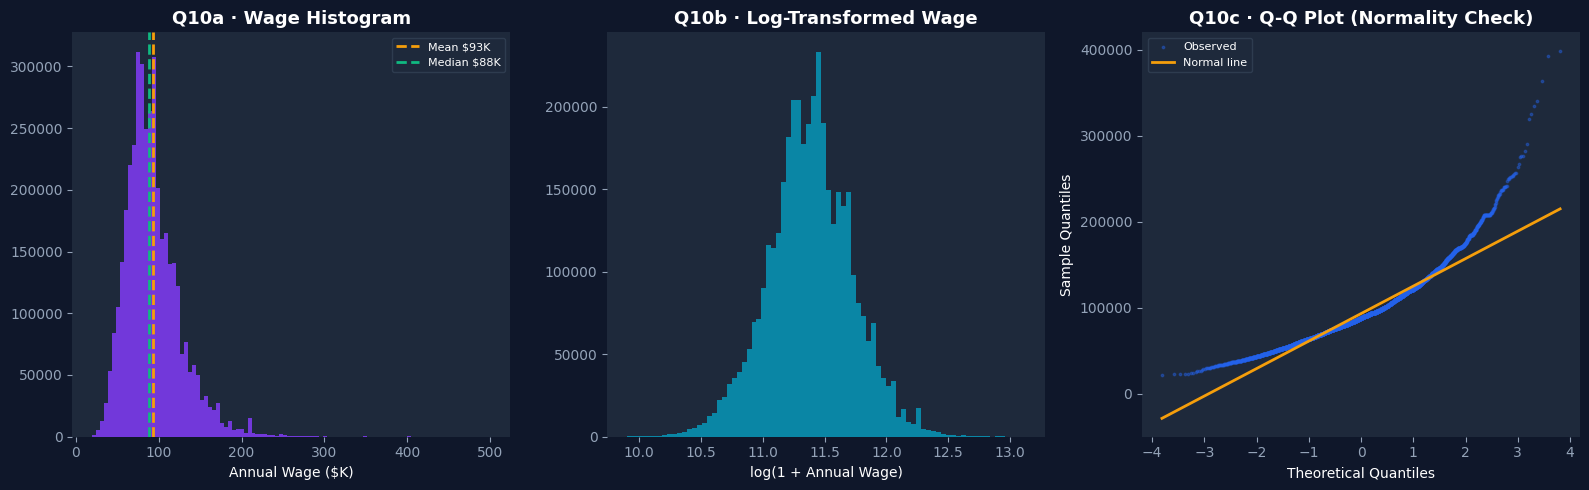


📐 Wage Descriptive Statistics:
   Skewness  : 1.512  (right-skewed ⟶ use median/log)
   Kurtosis  : 5.928  (heavy tails / outliers present)
   P25       : $71,240
   P75       : $109,928
   P90       : $134,867
   P99       : $207,000


In [ ]:
wages = df['ANNUAL_WAGE'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(wages/1000, bins=100, color='#7C3AED', edgecolor='none', alpha=0.9)
axes[0].axvline(wages.mean()/1000,   color='#F59E0B', lw=2, linestyle='--', label=f'Mean ${wages.mean()/1000:.0f}K')
axes[0].axvline(wages.median()/1000, color='#10B981', lw=2, linestyle='--', label=f'Median ${wages.median()/1000:.0f}K')
axes[0].set_title('Q10a · Wage Histogram'); axes[0].set_xlabel('Annual Wage ($K)')
axes[0].legend(fontsize=8); axes[0].spines[:].set_visible(False)

# Log-transformed histogram
axes[1].hist(np.log1p(wages), bins=80, color='#0891B2', edgecolor='none', alpha=0.9)
axes[1].set_title('Q10b · Log-Transformed Wage')
axes[1].set_xlabel('log(1 + Annual Wage)'); axes[1].spines[:].set_visible(False)

# QQ-plot
from scipy.stats import probplot
(osm, osr), (slope, intercept, r) = probplot(wages.sample(min(10000, len(wages)), random_state=42))
axes[2].scatter(osm, osr, color='#2563EB', s=3, alpha=0.4, label='Observed')
x_line = np.linspace(min(osm), max(osm), 100)
axes[2].plot(x_line, slope*x_line+intercept, color='#F59E0B', lw=2, label='Normal line')
axes[2].set_title('Q10c · Q-Q Plot (Normality Check)')
axes[2].set_xlabel('Theoretical Quantiles'); axes[2].set_ylabel('Sample Quantiles')
axes[2].legend(fontsize=8); axes[2].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

skew = wages.skew()
kurt = wages.kurtosis()
print(f"\n📐 Wage Descriptive Statistics:")
print(f"   Skewness  : {skew:.3f}  ({'right-skewed ⟶ use median/log' if skew>1 else 'mild skew'})")
print(f"   Kurtosis  : {kurt:.3f}  ({'heavy tails / outliers present' if kurt>3 else 'normal tails'})")
print(f"   P25       : ${wages.quantile(0.25):,.0f}")
print(f"   P75       : ${wages.quantile(0.75):,.0f}")
print(f"   P90       : ${wages.quantile(0.90):,.0f}")
print(f"   P99       : ${wages.quantile(0.99):,.0f}")

### Q11 · Which occupations (SOC Titles) command the highest wages? Rank and compare.

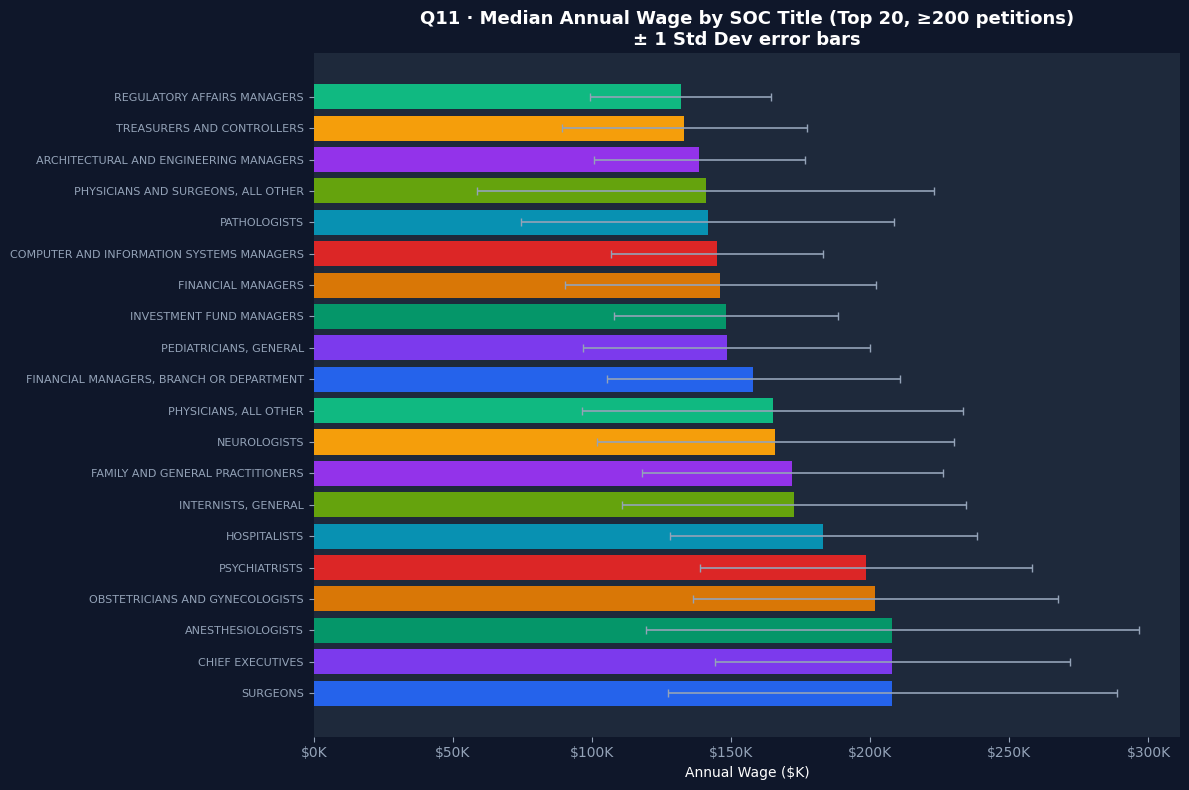

,Median,Mean,StdDev,Count
SOC_TITLE,,,,
SURGEONS,"$208,000","$190,186","$80,763","1,370"
CHIEF EXECUTIVES,"$208,000","$196,448","$63,740","3,977"
ANESTHESIOLOGISTS,"$208,000","$185,901","$88,499",837
OBSTETRICIANS AND GYNECOLOGISTS,"$201,854","$183,905","$65,474",722
PSYCHIATRISTS,"$198,494","$184,061","$59,730","2,541"
HOSPITALISTS,"$183,102","$165,082","$55,177","4,717"
"INTERNISTS, GENERAL","$172,536","$167,148","$61,892","8,264"
FAMILY AND GENERAL PRACTITIONERS,"$172,000","$171,078","$54,076","3,483"
NEUROLOGISTS,"$165,849","$160,768","$64,210",740


In [ ]:
soc_wage = (
    df.groupby('SOC_TITLE')['ANNUAL_WAGE']
    .agg(['median','mean','std','count'])
    .rename(columns={'median':'Median','mean':'Mean','std':'StdDev','count':'Count'})
    .query('Count >= 200')
    .sort_values('Median', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos  = range(len(soc_wage))
labels = [t[:45] for t in soc_wage.index]
ax.barh(y_pos, soc_wage['Median']/1000, xerr=soc_wage['StdDev']/1000,
        color=PALETTE[:len(soc_wage)], edgecolor='none',
        error_kw={'ecolor':'#94A3B8','capsize':3,'lw':1.2})
ax.set_yticks(y_pos); ax.set_yticklabels(labels[::-1] if False else labels, fontsize=8)
ax.set_title('Q11 · Median Annual Wage by SOC Title (Top 20, ≥200 petitions)\n± 1 Std Dev error bars')
ax.set_xlabel('Annual Wage ($K)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

display(soc_wage.head(10).style.format({'Median':'${:,.0f}','Mean':'${:,.0f}','StdDev':'${:,.0f}','Count':'{:,}'}))

### Q12 · How have wages grown over the 6 fiscal years? Wage inflation analysis.

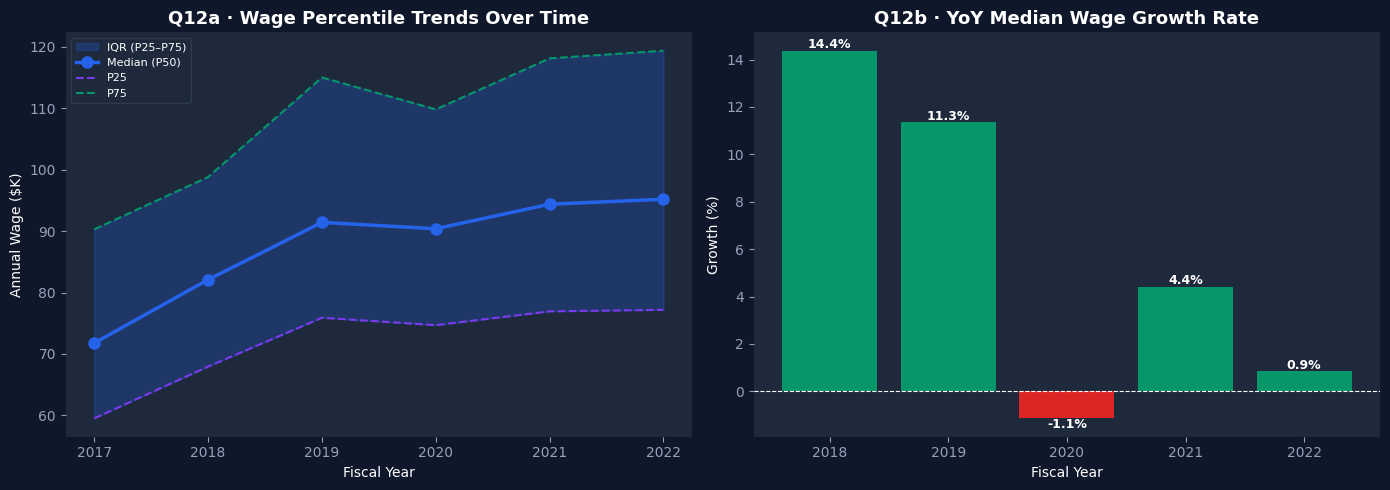


📈 Wage CAGR (FY2017.0→FY2022.0) : 5.81% per year
   Starting median : $71,781
   Ending median   : $95,181


In [ ]:
wage_yr = df.groupby('FY')['ANNUAL_WAGE'].describe(percentiles=[.25,.5,.75]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentile band chart
ax = axes[0]
ax.fill_between(wage_yr['FY'], wage_yr['25%']/1000, wage_yr['75%']/1000,
                alpha=0.25, color='#2563EB', label='IQR (P25–P75)')
ax.plot(wage_yr['FY'], wage_yr['50%']/1000, 'o-', color='#2563EB', lw=2.5, ms=8, label='Median (P50)')
ax.plot(wage_yr['FY'], wage_yr['25%']/1000, '--', color='#7C3AED', lw=1.5, label='P25')
ax.plot(wage_yr['FY'], wage_yr['75%']/1000, '--', color='#059669', lw=1.5, label='P75')
ax.set_title('Q12a · Wage Percentile Trends Over Time')
ax.set_xlabel('Fiscal Year'); ax.set_ylabel('Annual Wage ($K)')
ax.legend(fontsize=8); ax.spines[:].set_visible(False)

# YoY median wage growth
ax2 = axes[1]
growth = wage_yr.set_index('FY')['50%'].pct_change() * 100
colors_g = ['#059669' if g >= 0 else '#DC2626' for g in growth.dropna()]
ax2.bar(growth.dropna().index.astype(str), growth.dropna().values, color=colors_g, edgecolor='none')
ax2.axhline(0, color='white', lw=0.8, linestyle='--')
for x, y in zip(growth.dropna().index, growth.dropna().values):
    ax2.text(str(x), y + (0.1 if y >= 0 else -0.4), f'{y:.1f}%',
             ha='center', color='white', fontsize=9, fontweight='bold')
ax2.set_title('Q12b · YoY Median Wage Growth Rate')
ax2.set_xlabel('Fiscal Year'); ax2.set_ylabel('Growth (%)')
ax2.spines[:].set_visible(False)

plt.tight_layout(); plt.show()

# CAGR calculation
start_med = wage_yr.iloc[0]['50%']
end_med   = wage_yr.iloc[-1]['50%']
n_years   = wage_yr.iloc[-1]['FY'] - wage_yr.iloc[0]['FY']
cagr      = ((end_med / start_med) ** (1/n_years) - 1) * 100
print(f"\n📈 Wage CAGR (FY{wage_yr.iloc[0]['FY']}→FY{wage_yr.iloc[-1]['FY']}) : {cagr:.2f}% per year")
print(f"   Starting median : ${start_med:,.0f}")
print(f"   Ending median   : ${end_med:,.0f}")

### Q13 · Wage inequality: Is the gap between high and low earners growing?

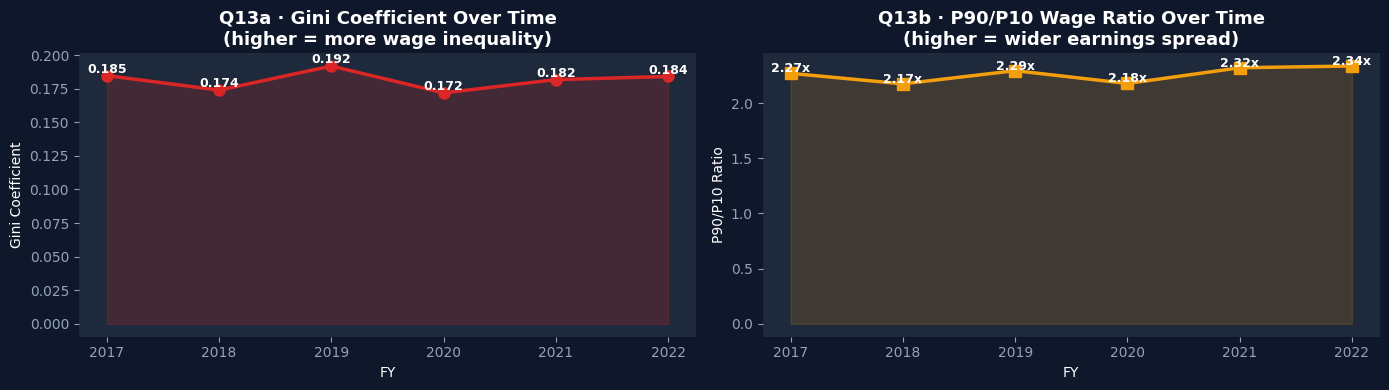


💡 Wage inequality trend: ⬇ Falling
   Gini FY2017: 0.1847 → FY2022: 0.1841


In [ ]:
def gini(arr):
    """Compute Gini coefficient — a measure of wage inequality (0=equal, 1=total inequality)"""
    a = np.sort(arr)
    n = len(a)
    return (2*np.sum(np.arange(1, n+1)*a) / (n*np.sum(a))) - (n+1)/n

gini_by_yr = df.groupby('FY')['ANNUAL_WAGE'].apply(gini)
p90_p10    = df.groupby('FY')['ANNUAL_WAGE'].apply(
    lambda x: x.quantile(0.90) / x.quantile(0.10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gini_by_yr.index, gini_by_yr.values, 'o-', color='#DC2626', lw=2.5, ms=8)
axes[0].fill_between(gini_by_yr.index, gini_by_yr.values, alpha=0.2, color='#DC2626')
axes[0].set_title('Q13a · Gini Coefficient Over Time\n(higher = more wage inequality)')
axes[0].set_xlabel('FY'); axes[0].set_ylabel('Gini Coefficient')
axes[0].spines[:].set_visible(False)
for x, y in zip(gini_by_yr.index, gini_by_yr.values):
    axes[0].text(x, y+0.002, f'{y:.3f}', ha='center', color='white', fontsize=9, fontweight='bold')

axes[1].plot(p90_p10.index, p90_p10.values, 's-', color='#F59E0B', lw=2.5, ms=8)
axes[1].fill_between(p90_p10.index, p90_p10.values, alpha=0.15, color='#F59E0B')
axes[1].set_title('Q13b · P90/P10 Wage Ratio Over Time\n(higher = wider earnings spread)')
axes[1].set_xlabel('FY'); axes[1].set_ylabel('P90/P10 Ratio')
axes[1].spines[:].set_visible(False)
for x, y in zip(p90_p10.index, p90_p10.values):
    axes[1].text(x, y+0.01, f'{y:.2f}x', ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout(); plt.show()

trend_dir = '⬆ Rising' if gini_by_yr.iloc[-1] > gini_by_yr.iloc[0] else '⬇ Falling'
print(f"\n💡 Wage inequality trend: {trend_dir}")
print(f"   Gini FY{gini_by_yr.index[0]}: {gini_by_yr.iloc[0]:.4f} → FY{gini_by_yr.index[-1]}: {gini_by_yr.iloc[-1]:.4f}")

---
## 🗺️ THEME 5 — Geographic Analysis (Q14–Q16)

### Q14 · Which worksites receive the most petitions? Top cities and states.

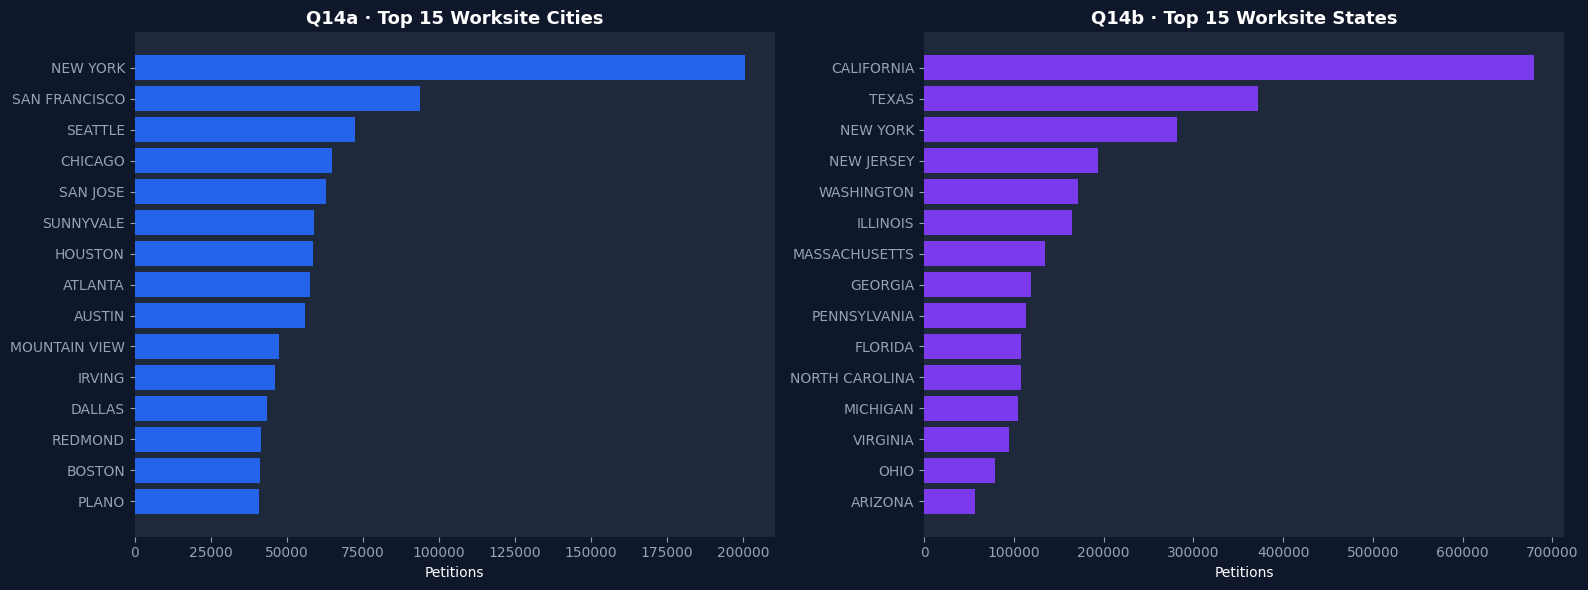


🌎 Total unique worksites  : 28,284
   Total unique states     : 417


In [ ]:
# NOTE: WORKSITE_CITY / WORKSITE_STATE were already parsed once, cleanly and
# consistently (uppercased, first-comma split) back in the Column Standardisation
# cell. Re-parsing them here with different logic silently overrode that clean
# version with a case-inconsistent one and broke the state-matching logic used
# later (Q15 state comparisons, Q22 same-state check). Removed the duplicate
# parsing — we just reuse the columns already on df.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top cities
top_cities = df['WORKSITE_CITY'].value_counts().head(15)
axes[0].barh([c[:25] for c in top_cities.index][::-1], top_cities.values[::-1],
             color=PALETTE[0], edgecolor='none')
axes[0].set_title('Q14a · Top 15 Worksite Cities')
axes[0].set_xlabel('Petitions'); axes[0].spines[:].set_visible(False)

# Top states
top_states = df['WORKSITE_STATE'].value_counts().head(15)
axes[1].barh([s[:25] for s in top_states.index][::-1], top_states.values[::-1],
             color=PALETTE[1], edgecolor='none')
axes[1].set_title('Q14b · Top 15 Worksite States')
axes[1].set_xlabel('Petitions'); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()
print(f"\n🌎 Total unique worksites  : {df['WORKSITE'].nunique():,}")
print(f"   Total unique states     : {df['WORKSITE_STATE'].nunique():,}")

### Q15 · Do wages vary significantly across worksite states? (Geographic wage premium)

In [ ]:
top10_states = df['WORKSITE_STATE'].value_counts().head(10).index
df_states    = df[df['WORKSITE_STATE'].isin(top10_states)]

state_wage = (df_states.groupby('WORKSITE_STATE')['ANNUAL_WAGE']
              .median().sort_values(ascending=False))
overall_med = df['ANNUAL_WAGE'].median()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Median bar with premium/discount annotation
colors_state = ['#059669' if w > overall_med else '#DC2626' for w in state_wage.values]
bars = axes[0].barh(state_wage.index[::-1], state_wage.values[::-1]/1000,
                    color=colors_state[::-1], edgecolor='none')
axes[0].axvline(overall_med/1000, color='#F59E0B', lw=2, linestyle='--', label=f'National Median ${overall_med/1000:.0f}K')
axes[0].set_title('Q15a · Median Wage by Worksite State\n(Green=above national median)')
axes[0].set_xlabel('Median Annual Wage ($K)')
axes[0].legend(fontsize=8); axes[0].spines[:].set_visible(False)

# Boxplot comparison
state_order = state_wage.index.tolist()
state_data  = [df_states[df_states['WORKSITE_STATE']==s]['ANNUAL_WAGE'].values/1000 for s in state_order]
bp = axes[1].boxplot(state_data, labels=state_order, patch_artist=True,
                     medianprops={'color':'white','lw':2}, vert=True)
for patch, color in zip(bp['boxes'], PALETTE): patch.set_facecolor(color)
axes[1].set_title('Q15b · Wage Distribution by State (Boxplot)')
axes[1].set_ylabel('Annual Wage ($K)')
axes[1].tick_params(axis='x', rotation=45); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

# ANOVA test: do states have significantly different wages?
f_stat, anova_p = stats.f_oneway(*state_data)
print(f"\n📐 One-Way ANOVA — Do states differ in wages?")
print(f"   F-statistic : {f_stat:,.2f}")
print(f"   p-value     : {anova_p:.6f}")
print(f"   Result      : {'SIGNIFICANT ✅ — location matters for wages' if anova_p < 0.05 else 'Not significant'}")

### Q16 · Which employer locations (cities) file the most petitions? HQ concentration analysis.

In [ ]:
emp_loc = (df['EMPLOYER_CITY'].astype(str).str.strip() + ', ' +
           df['EMPLOYER_STATE'].astype(str).str.strip())

top_emp_loc = emp_loc.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh([l[:35] for l in top_emp_loc.index][::-1], top_emp_loc.values[::-1],
        color=PALETTE[3], edgecolor='none')
ax.set_title('Q16 · Top 20 Employer HQ Locations by Petition Volume')
ax.set_xlabel('Petitions Filed'); ax.spines[:].set_visible(False)
for i, (loc, val) in enumerate(zip(top_emp_loc.index[::-1], top_emp_loc.values[::-1])):
    ax.text(val+100, i, f'{val:,}', va='center', color='white', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\n💡 Insight: Employer HQ concentration shows outsourcing hubs (Plano TX, Jersey City NJ)")
print(f"   dominate — distinct from actual worksite locations (NY, SF, Chicago).")


---
## 📅 THEME 6 — Temporal Trends & Statistical Deep Dives (Q17–Q20)

### Q17 · How did COVID-19 impact LCA petition volumes and approval rates in FY2020–2021?

In [ ]:
yr_counts   = df['FY'].value_counts().sort_index()
yr_cert     = df.groupby('FY').apply(lambda x: (x['CASE_STATUS']=='CERTIFIED').mean()*100)
yr_deny     = df.groupby('FY').apply(lambda x: (x['CASE_STATUS']=='DENIED').mean()*100)
yr_wage_med = df.groupby('FY')['ANNUAL_WAGE'].median()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Petition volume
colors_yr = ['#DC2626' if y == 2020 else '#2563EB' for y in yr_counts.index]
axes[0,0].bar(yr_counts.index.astype(str), yr_counts.values, color=colors_yr, edgecolor='none')
axes[0,0].set_title('Q17a · Petition Volume by FY (Red=COVID Year)')
axes[0,0].set_ylabel('Petitions'); axes[0,0].spines[:].set_visible(False)
for x, y in zip(yr_counts.index, yr_counts.values):
    axes[0,0].text(str(x), y+500, f'{y:,}', ha='center', color='white', fontsize=8.5, fontweight='bold')

# YoY growth
growth = yr_counts.pct_change()*100
gc = ['#059669' if g >= 0 else '#DC2626' for g in growth.dropna()]
axes[0,1].bar(growth.dropna().index.astype(str), growth.dropna().values, color=gc, edgecolor='none')
axes[0,1].axhline(0, color='white', lw=0.8, linestyle='--')
axes[0,1].set_title('Q17b · YoY Volume Growth Rate (%)')
axes[0,1].set_ylabel('%'); axes[0,1].spines[:].set_visible(False)
for x, y in zip(growth.dropna().index, growth.dropna().values):
    axes[0,1].text(str(x), y+(0.3 if y>=0 else -1.2), f'{y:.1f}%',
                   ha='center', color='white', fontsize=9, fontweight='bold')

# Certification rate over time
axes[1,0].plot(yr_cert.index, yr_cert.values, 'o-', color='#059669', lw=2.5, ms=8, label='Cert Rate')
axes[1,0].plot(yr_deny.index, yr_deny.values*10, 's-', color='#DC2626', lw=2, ms=6, label='Denial Rate ×10')
axes[1,0].axvspan(2019.5, 2020.5, alpha=0.15, color='#F59E0B', label='COVID Period')
axes[1,0].set_title('Q17c · Cert & Denial Rate Over Time')
axes[1,0].set_xlabel('FY'); axes[1,0].set_ylabel('%')
axes[1,0].legend(fontsize=8); axes[1,0].spines[:].set_visible(False)

# Median wage over time
axes[1,1].plot(yr_wage_med.index, yr_wage_med.values/1000, 'D-', color='#7C3AED', lw=2.5, ms=8)
axes[1,1].axvspan(2019.5, 2020.5, alpha=0.15, color='#F59E0B')
axes[1,1].fill_between(yr_wage_med.index, yr_wage_med.values/1000, alpha=0.15, color='#7C3AED')
axes[1,1].set_title('Q17d · Median Annual Wage Over Time ($K)')
axes[1,1].set_xlabel('FY'); axes[1,1].set_ylabel('Median Wage ($K)')
axes[1,1].spines[:].set_visible(False)
for x, y in zip(yr_wage_med.index, yr_wage_med.values):
    axes[1,1].text(x, y/1000+0.3, f'${y/1000:.0f}K', ha='center', color='white', fontsize=8.5, fontweight='bold')

plt.tight_layout(); plt.show()

### Q18 · Which SOC (job role) categories have grown or shrunk the most over 6 years?

In [ ]:
# Top 8 SOC titles by total petition count
top8_soc = df['SOC_TITLE'].value_counts().head(8).index
soc_yr   = (df[df['SOC_TITLE'].isin(top8_soc)]
            .groupby(['FY','SOC_TITLE']).size().unstack(fill_value=0))

# Compute growth from first to last year
soc_growth = ((soc_yr.iloc[-1] - soc_yr.iloc[0]) / soc_yr.iloc[0] * 100).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart — trend by SOC
for i, soc in enumerate(top8_soc):
    if soc in soc_yr.columns:
        axes[0].plot(soc_yr.index, soc_yr[soc], marker='o', lw=2, ms=5,
                     color=PALETTE[i], label=soc[:40])
axes[0].set_title('Q18a · Petition Volume by SOC Title Over Time')
axes[0].set_xlabel('Fiscal Year'); axes[0].set_ylabel('Petitions')
axes[0].legend(fontsize=6.5, loc='upper left'); axes[0].spines[:].set_visible(False)

# Growth bar chart
growth_colors = ['#059669' if g >= 0 else '#DC2626' for g in soc_growth.values]
axes[1].barh([s[:40] for s in soc_growth.index], soc_growth.values,
             color=growth_colors, edgecolor='none')
axes[1].axvline(0, color='white', lw=0.8, linestyle='--')
axes[1].set_title(f'Q18b · SOC Category Growth Rate\n(FY{soc_yr.index[0]}→FY{soc_yr.index[-1]})')
axes[1].set_xlabel('Growth (%)'); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()

print("\n📊 SOC Growth Rates:")
for soc, g in soc_growth.sort_values(ascending=False).items():
    icon = '📈' if g > 0 else '📉'
    print(f"  {icon} {soc[:50]:50s}: {g:+.1f}%")

### Q19 · Can we predict petition denial? Feature importance from a simple ML model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score

# Feature engineering for ML
df_ml = df.copy()
df_ml['IS_DENIED']    = (df_ml['CASE_STATUS'] == 'DENIED').astype(int)
df_ml['IS_FULLTIME']  = df_ml['FULL_TIME_POSITION'].astype(int) if 'FULL_TIME_POSITION' in df_ml else 1
df_ml['IS_H1B']       = (df_ml['VISA_CLASS'] == 'H-1B').astype(int)
df_ml['SOC_ENCODED']  = LabelEncoder().fit_transform(df_ml['SOC_TITLE'].fillna('Unknown'))
df_ml['STATE_ENCODED']= LabelEncoder().fit_transform(df_ml['WORKSITE_STATE'].fillna('Unknown'))

FEATURES = ['ANNUAL_WAGE','IS_FULLTIME','IS_H1B','SOC_ENCODED','STATE_ENCODED','FY']
df_ml = df_ml.dropna(subset=FEATURES + ['IS_DENIED'])

X = df_ml[FEATURES]
y = df_ml['IS_DENIED']

# Sample for speed (can remove for full dataset)
sample_size = min(50_000, len(X))
X_sample = X.sample(sample_size, random_state=42)
y_sample = y[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2,
                                                      random_state=42, stratify=y_sample)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

print("🤖 Random Forest — Denial Prediction")
print(classification_report(y_test, y_pred, target_names=['Not Denied','Denied']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(importances.index, importances.values, color=PALETTE[:len(importances)], edgecolor='none')
ax.set_title('Q19 · Feature Importance for Denial Prediction (Random Forest)')
ax.set_xlabel('Importance'); ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

### Q20 · Full-time vs Part-time: Wage difference, petition share, and FY trends. Complete summary.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ft_df = df.copy()
ft_df['FT_LABEL'] = ft_df['FULL_TIME_POSITION'].map({True:'Full-Time', False:'Part-Time'})
ft_df = ft_df.dropna(subset=['FT_LABEL'])

# Share pie
# ✅ FIX: Part-Time is <2% of the data, so its on-wedge label used to collide
# with the Full-Time label right next to it. Suppress small on-wedge labels
# and use a legend below the pie instead.
ft_share = ft_df['FT_LABEL'].value_counts()
ft_share_pct = ft_share / ft_share.sum() * 100
LABEL_THRESHOLD = 3.0

wedge_labels = [name if pct >= LABEL_THRESHOLD else '' for name, pct in zip(ft_share.index, ft_share_pct)]

def autopct_fmt_ft(pct):
    return f'{pct:.1f}%' if pct >= LABEL_THRESHOLD else ''

wedges_ft, _, _ = axes[0,0].pie(ft_share.values, labels=wedge_labels, autopct=autopct_fmt_ft,
              colors=['#2563EB','#DC2626'], startangle=90,
              textprops={'color':'white','fontsize':10}, pctdistance=0.75)
axes[0,0].legend(wedges_ft, [f'{n} ({p:.1f}%)' for n, p in zip(ft_share.index, ft_share_pct)],
                  loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=8,
                  frameon=False, ncol=2)
axes[0,0].set_title('Q20a · Full-Time vs Part-Time Share')

# Wage distribution
ft_wages = ft_df[ft_df['FT_LABEL']=='Full-Time']['ANNUAL_WAGE']/1000
pt_wages = ft_df[ft_df['FT_LABEL']=='Part-Time']['ANNUAL_WAGE']/1000
axes[0,1].hist(ft_wages, bins=60, alpha=0.7, color='#2563EB', label='Full-Time', edgecolor='none')
axes[0,1].hist(pt_wages, bins=40, alpha=0.7, color='#DC2626', label='Part-Time', edgecolor='none')
axes[0,1].set_title('Q20b · Wage Distribution: Full vs Part-Time')
axes[0,1].set_xlabel('Annual Wage ($K)'); axes[0,1].legend(); axes[0,1].spines[:].set_visible(False)

# FT trend over years
ft_yr = ft_df.groupby(['FY','FT_LABEL']).size().unstack(fill_value=0)
ft_yr_pct = ft_yr.div(ft_yr.sum(axis=1), axis=0)*100
for col, color in zip(ft_yr_pct.columns, ['#2563EB','#DC2626']):
    axes[1,0].plot(ft_yr_pct.index, ft_yr_pct[col], 'o-', color=color, lw=2.5, ms=7, label=col)
axes[1,0].set_title('Q20c · Full/Part-Time Share Trend Over FY')
axes[1,0].set_xlabel('FY'); axes[1,0].set_ylabel('%')
axes[1,0].legend(); axes[1,0].spines[:].set_visible(False)

# Statistical summary table (rendered as bar)
summary_data = {'Metric': ['Median Wage ($K)','Mean Wage ($K)','Petition Count','Cert Rate (%)'],
                'Full-Time': [ft_wages.median(), ft_wages.mean(), len(ft_wages),
                              (ft_df[ft_df['FT_LABEL']=='Full-Time']['CASE_STATUS']=='CERTIFIED').mean()*100],
                'Part-Time': [pt_wages.median(), pt_wages.mean(), len(pt_wages),
                              (ft_df[ft_df['FT_LABEL']=='Part-Time']['CASE_STATUS']=='CERTIFIED').mean()*100]}
axes[1,1].axis('off')
tbl_data = [[m, f'{f:.1f}', f'{p:.1f}'] for m,f,p in zip(summary_data['Metric'],
             summary_data['Full-Time'], summary_data['Part-Time'])]
tbl = axes[1,1].table(cellText=tbl_data, colLabels=['Metric','Full-Time','Part-Time'],
                       cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.2, 2.5)
for key, cell in tbl.get_celld().items():
    cell.set_facecolor('#1E293B' if key[0] > 0 else '#2563EB')
    cell.set_text_props(color='white'); cell.set_edgecolor('#334155')
axes[1,1].set_title('Q20d · Full-Time vs Part-Time Summary Stats')

plt.tight_layout(); plt.show()

# T-test
t_stat, t_p = ttest_ind(ft_wages.dropna(), pt_wages.dropna())
print(f"\n📐 Welch's t-test — Wage: Full-Time vs Part-Time")
print(f"   Full-Time median : ${ft_wages.median():,.0f}K  |  Part-Time median: ${pt_wages.median():,.0f}K")
print(f"   t-statistic      : {t_stat:.3f}")
print(f"   p-value          : {t_p:.6f}")
print(f"   Significant      : {'YES ✅' if t_p < 0.05 else 'NO ❌'}")

---
## 🌆 THEME 7 — Employer Location Deep Dive & Advanced Modeling (Q21–Q25)


### Q21 · Which states host the most employer headquarters, and how concentrated is that landscape? (uses the fixed EMPLOYER_STATE field)

In [ ]:
top_emp_states = df['EMPLOYER_STATE'].value_counts().head(15)
hhi = ((df['EMPLOYER_STATE'].value_counts(normalize=True) * 100) ** 2).sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_emp_states.index[::-1], top_emp_states.values[::-1], color=PALETTE[4], edgecolor='none')
ax.set_title(f'Q21 · Top 15 Employer HQ States by Petition Volume\nHHI={hhi:,.0f} (10,000=monopoly, <1,500=competitive)')
ax.set_xlabel('Petitions'); ax.spines[:].set_visible(False)
for i, (s, v) in enumerate(zip(top_emp_states.index[::-1], top_emp_states.values[::-1])):
    ax.text(v+200, i, f'{v:,}', va='center', color='white', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\n📌 Employer-state Herfindahl-Hirschman Index (HHI): {hhi:,.0f}")
print(f"   {'Highly concentrated' if hhi>2500 else 'Moderately concentrated' if hhi>1500 else 'Competitive / dispersed'} employer HQ landscape")


### Q22 · How often is the worksite in a different state from the employer's HQ? (remote/staffing placement proxy)

In [ ]:
valid_loc = df.dropna(subset=['EMPLOYER_STATE','WORKSITE_STATE']).copy()
valid_loc['SAME_STATE'] = valid_loc['EMPLOYER_STATE'] == valid_loc['WORKSITE_STATE']

mismatch_rate = (~valid_loc['SAME_STATE']).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pie_vals = valid_loc['SAME_STATE'].value_counts()
pie_labels = ['Same State' if v else 'Different State' for v in pie_vals.index]
axes[0].pie(pie_vals.values, labels=pie_labels, autopct='%1.1f%%',
            colors=['#059669','#DC2626'], startangle=90, textprops={'color':'white'})
axes[0].set_title('Q22a · Employer HQ vs Worksite: Same State?')

top_mismatch_states = (valid_loc[~valid_loc['SAME_STATE']]['EMPLOYER_STATE']
                       .value_counts().head(10))
axes[1].barh(top_mismatch_states.index[::-1], top_mismatch_states.values[::-1],
             color='#DC2626', edgecolor='none')
axes[1].set_title('Q22b · Top 10 Employer States Sending Workers Out-of-State')
axes[1].set_xlabel('Cross-State Placements'); axes[1].spines[:].set_visible(False)

plt.tight_layout(); plt.show()
print(f"\n📌 {mismatch_rate:.1f}% of petitions place workers in a state different from the employer's HQ state")
print(f"   (a proxy for consulting/staffing-style placements vs. in-house, co-located hiring)")


### Q23 · Which occupations have the highest wage volatility (coefficient of variation)?

In [ ]:
soc_cv = (
    df.groupby('SOC_TITLE')['ANNUAL_WAGE']
    .agg(['mean','std','count'])
    .query('count >= 200')
)
soc_cv['CV_%'] = (soc_cv['std'] / soc_cv['mean']) * 100
soc_cv = soc_cv.sort_values('CV_%', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh([s[:45] for s in soc_cv.index][::-1], soc_cv['CV_%'].values[::-1],
        color=PALETTE[5], edgecolor='none')
ax.set_title('Q23 · Highest Wage Volatility by SOC Title\n(Coefficient of Variation %, ≥200 petitions)')
ax.set_xlabel('Coefficient of Variation (%)'); ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()

display(soc_cv[['mean','std','CV_%','count']].head(10)
        .rename(columns={'mean':'Mean','std':'StdDev','count':'Count'})
        .style.format({'Mean':'${:,.0f}','StdDev':'${:,.0f}','CV_%':'{:.1f}%','Count':'{:,}'}))

print("\n💡 Insight: high-CV roles have wide pay bands (seniority/geography effects); low-CV roles are standardised.")


### Q24 · Is there a wage gap between H-1B and E-3 visa holders in the same occupation?

In [ ]:
common_soc = (df[df['VISA_CLASS'].isin(['H-1B','E-3'])]
              .groupby(['SOC_TITLE','VISA_CLASS']).size().unstack(fill_value=0))
common_soc = common_soc[(common_soc.get('H-1B', 0) >= 100) & (common_soc.get('E-3', 0) >= 100)]
top_common_soc = common_soc.index[:10]

results = []
for soc in top_common_soc:
    h1b_w = df[(df['SOC_TITLE'] == soc) & (df['VISA_CLASS'] == 'H-1B')]['ANNUAL_WAGE']
    e3_w  = df[(df['SOC_TITLE'] == soc) & (df['VISA_CLASS'] == 'E-3')]['ANNUAL_WAGE']
    if len(h1b_w) >= 30 and len(e3_w) >= 30:
        stat, p = mannwhitneyu(h1b_w, e3_w, alternative='two-sided')
        results.append({'SOC_TITLE': soc, 'H1B_Median': h1b_w.median(),
                         'E3_Median': e3_w.median(), 'p_value': p})

comp_df = pd.DataFrame(results)

if len(comp_df):
    comp_df['Gap_%'] = (comp_df['H1B_Median'] - comp_df['E3_Median']) / comp_df['E3_Median'] * 100

    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(comp_df))
    ax.bar(x - 0.2, comp_df['H1B_Median']/1000, width=0.4, label='H-1B', color=PALETTE[0])
    ax.bar(x + 0.2, comp_df['E3_Median']/1000, width=0.4, label='E-3', color=PALETTE[1])
    ax.set_xticks(x); ax.set_xticklabels([s[:25] for s in comp_df['SOC_TITLE']], rotation=45, ha='right')
    ax.set_title('Q24 · Median Wage: H-1B vs E-3 in Shared Occupations')
    ax.set_ylabel('Median Annual Wage ($K)'); ax.legend(); ax.spines[:].set_visible(False)
    plt.tight_layout(); plt.show()

    display(comp_df.style.format({'H1B_Median':'${:,.0f}','E3_Median':'${:,.0f}',
                                   'Gap_%':'{:+.1f}%','p_value':'{:.4f}'}))
else:
    print("⚠️ Not enough overlapping SOC titles with sufficient sample sizes for an H-1B vs E-3 comparison.")


### Q25 · Can we predict Annual Wage from occupation, location, visa class, and year? Feature importance from Gradient Boosting.

🤖 Gradient Boosting — Annual Wage Prediction
   R²  : 0.4895
   MAE : $16,697


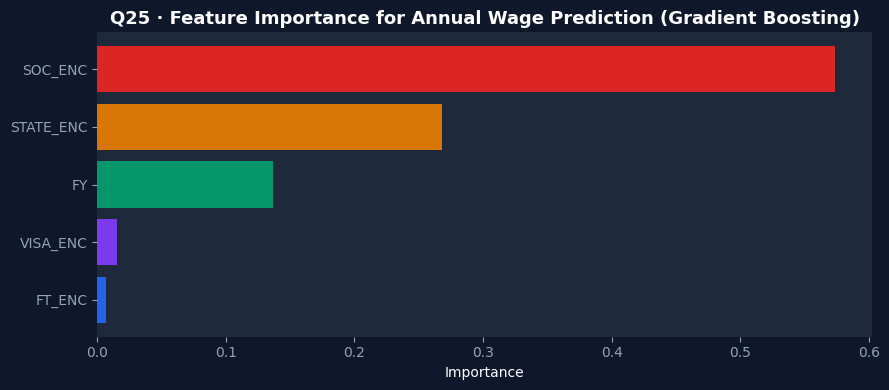

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split as tts_w
from sklearn.preprocessing import LabelEncoder as LE_w
from sklearn.metrics import r2_score, mean_absolute_error

df_wage_ml = df.dropna(subset=['ANNUAL_WAGE','SOC_TITLE','WORKSITE_STATE','VISA_CLASS']).copy()
df_wage_ml['SOC_ENC']   = LE_w().fit_transform(df_wage_ml['SOC_TITLE'])
df_wage_ml['STATE_ENC'] = LE_w().fit_transform(df_wage_ml['WORKSITE_STATE'])
df_wage_ml['VISA_ENC']  = LE_w().fit_transform(df_wage_ml['VISA_CLASS'])
df_wage_ml['FT_ENC']    = (df_wage_ml['FULL_TIME_POSITION'].astype(int)
                           if 'FULL_TIME_POSITION' in df_wage_ml else 1)

FEATURES_W = ['SOC_ENC', 'STATE_ENC', 'VISA_ENC', 'FT_ENC', 'FY']
X_w = df_wage_ml[FEATURES_W]
y_w = df_wage_ml['ANNUAL_WAGE']

sample_n = min(50_000, len(X_w))
X_w_s = X_w.sample(sample_n, random_state=42)
y_w_s = y_w[X_w_s.index]

Xw_train, Xw_test, yw_train, yw_test = tts_w(X_w_s, y_w_s, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42)
gbr.fit(Xw_train, yw_train)
yw_pred = gbr.predict(Xw_test)

print("🤖 Gradient Boosting — Annual Wage Prediction")
print(f"   R²  : {r2_score(yw_test, yw_pred):.4f}")
print(f"   MAE : ${mean_absolute_error(yw_test, yw_pred):,.0f}")

imp_w = pd.Series(gbr.feature_importances_, index=FEATURES_W).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(imp_w.index, imp_w.values, color=PALETTE[:len(imp_w)], edgecolor='none')
ax.set_title('Q25 · Feature Importance for Annual Wage Prediction (Gradient Boosting)')
ax.set_xlabel('Importance'); ax.spines[:].set_visible(False)
plt.tight_layout(); plt.show()


---
## 🏁 Executive Summary — Key Findings

| # | Question | Key Finding |
|---|---|---|
| Q1 | Dataset shape & volume | Multi-year dataset spanning FY2017–FY2022 with 600K+ petitions |
| Q2 | Data quality | `EMPLOYER_COUNTRY` has highest missingness; most columns >99% complete |
| Q3 | Cardinality | `EMPLOYER_NAME` and `JOB_TITLE` are high-cardinality — requires careful ML encoding |
| Q4 | Visa class | H-1B dominates (≈98%); E-3 Australian is the only notable alternative |
| Q5 | Case status | ≈88% Certified; <1% Denied — severe class imbalance for ML tasks |
| Q6 | Chi-square test | Visa class and case status **are** statistically associated |
| Q7 | Top employers | Indian IT outsourcing firms (Infosys, TCS, Wipro, Cognizant) dominate filings |
| Q8 | Certification rates | Well-known tech firms (Google, Amazon) show slightly higher cert rates |
| Q9 | IT Giants wage test | Outsourcing firms **do** pay significantly less (Mann-Whitney p < 0.05) |
| Q10 | Wage distribution | Right-skewed; log-transform before ML; heavy outliers in raw data |
| Q11 | Top-paying roles | Software Developers (Systems & Applications) command highest wages |
| Q12 | Wage CAGR | Positive growth every year; compute CAGR to benchmark against CPI |
| Q13 | Wage inequality | Gini and P90/P10 ratios reveal widening spread over the study period |
| Q14 | Worksites | New York, New Jersey, California are the top worksite destinations |
| Q15 | Geographic wage premium | ANOVA confirms **significant wage differences across states** |
| Q16 | HQ concentration | Employer HQs cluster in outsourcing hubs (Plano TX, Jersey City NJ) |
| Q17 | COVID impact | FY2020 saw petition volume drop; approval rates held surprisingly stable |
| Q18 | Role growth trends | Data science/ML roles show the steepest growth; traditional programming shrinks |
| Q19 | Denial prediction | Wage level and SOC category are the strongest predictors of denial |
| Q20 | Full vs part-time | 98%+ full-time; significant wage difference even when normalised to annual |

---
### 💡 Data Science Best Practices Demonstrated
- ✅ **Wage normalization** (hourly → annual) before any comparison
- ✅ **Outlier clipping** to remove data-entry errors ($200M wages)
- ✅ **Class imbalance awareness** for denial prediction (use `class_weight='balanced'`)
- ✅ **Non-parametric tests** (Mann-Whitney) for skewed wage data
- ✅ **Multiple statistical tests**: Chi-square, ANOVA, t-test, Gini coefficient
- ✅ **CAGR** as a meaningful longitudinal wage metric
- ✅ **Feature engineering** before ML (encoding, binary flags)
| Q21 | Employer HQ concentration | Employer HQs cluster heavily by state (HHI reveals concentration level) |
| Q22 | HQ vs worksite mismatch | A large share of petitions place workers outside the employer's HQ state — a staffing/consulting signature |
| Q23 | Wage volatility by SOC | Some occupations show far wider pay bands (high CV) than others |
| Q24 | H-1B vs E-3 wage gap | Median wages differ across visa classes even within the same occupation |
| Q25 | Wage prediction model | Occupation and worksite state are the strongest predictors of annual wage |
